### Resonant subspace comparison

We compare the dynamics prediction of FPT (so no micromotion or geometric correction). The time evolution of $\ket{a}$ and $\ket{b}$ is plotted for the FPT prediction with the resonant subspace $D={\ket{a};\ket{b}}$ and for $D={\ket{a};\ket{b};\ket{c}}$. The result is compared to the numerical solution of the 27-dimensional system. 

In [1]:
from utils import *
from FAPT import *
s = Simulation()
state_a = s.state_a
state_b = s.state_b

100%|█████████▉| 1999/2000 [03:29<00:00,  9.52it/s]


Plot gespeichert unter: Figure/resonant_subspace_comparison.pdf


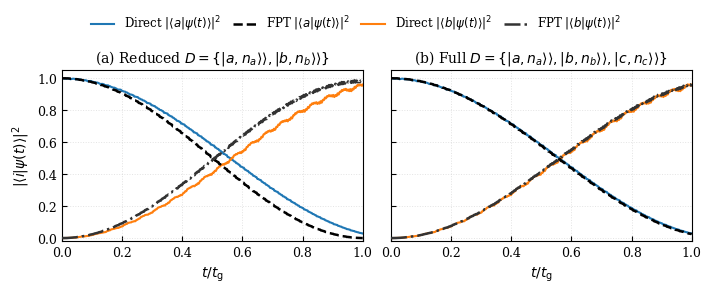

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# COLOR CONFIGURATION
# =============================================================================
# Hintergrund: Direkte Simulation (dezent/transparent)
COLOR_NUM_A = "#1f77b4"  # Blau
COLOR_NUM_B = "#ff7f0e"  # Orange

# Vordergrund: FPT Theorie (Dunkel / Schwarz)
COLOR_FPT_A = "#000000"  # Reines Schwarz für Zustand a
COLOR_FPT_B = "#333333"  # Dunkles Anthrazit für Zustand b

PAPER_STYLE = {
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "text.usetex": False,
}


def compare_resonant_subspaces(
    s,
    state_a,
    state_b,
    tg_ns=100.0,
    N_t=2000,
    rH=3,
    rW=2,
    savepath="Figure/resonant_subspace_comparison.pdf",
):
    plt.rcParams.update(PAPER_STYLE)

    # 1. Drive & Parameters
    t = np.linspace(0.0, tg_ns, N_t)
    A, wd = compute_cos_params(s, tg_ns)

    signal = lambda t, args=None: A * np.cos(wd * t)
    drive = lambda t: (wd, A)

    res_full = dict(s.resonances)
    res_ab = {state_a: res_full[state_a], state_b: res_full[state_b]}

    # 2. Numerische 27-D Dynamik
    amp_num = resonant_subspace_column_evolution(
        [s.H0, [s.V1, signal]], t, 0, debug=False, s=s
    )
    resonance_indices = {state: i for i, state in enumerate(res_full)}
    rows_num = [resonance_indices[state_a], resonance_indices[state_b]]
    pop_num = np.abs(amp_num[rows_num, :]) ** 2

    # 3. FPT-Dynamik (Robust bezüglich Vektorlänge)
    def get_fpt_pop(resonances):
        psi = Psi_t_from_Heff(
            rH,
            rW,
            drive,
            resonances,
            s.E_array,
            s.V1_dressed_array,
            initial_state=s.E_states[state_a],
            tlist=t,
            V0=None,
            include_geometric=False,
            include_micromotion=False,
            include_g_correction=False,
        )

        # Falls Psi im vollen Hilbertraum (27D) ist:
        if psi.shape[0] == len(s.E_array):
            return np.abs(psi[[state_a, state_b], :]) ** 2

        # Falls Psi nur im effektiven Subspace D liegt (Dimension 2 oder 3):
        subspace_keys = list(resonances.keys())
        idx_a = subspace_keys.index(state_a)
        idx_b = subspace_keys.index(state_b)
        return np.abs(psi[[idx_a, idx_b], :]) ** 2

    pop_ab = get_fpt_pop(res_ab)
    pop_full = get_fpt_pop(res_full)

    # 4. Plotting
    x = t / tg_ns
    fig, axes = plt.subplots(
        1, 2, figsize=(7.0, 2.7), sharex=True, sharey=True, constrained_layout=True
    )
    fig.get_layout_engine().set(rect=[0, 0, 1, 0.90])

    # Panel (a)
    line_num_a, = axes[0].plot(
        x, pop_num[0], color=COLOR_NUM_A, ls="-", lw=1.5, alpha=1, zorder=2,
        label=r"Direct $|\langle a|\psi(t)\rangle|^2$"
    )
    line_num_b, = axes[0].plot(
        x, pop_num[1], color=COLOR_NUM_B, ls="-", lw=1.5, alpha=1, zorder=2,
        label=r"Direct $|\langle b|\psi(t)\rangle|^2$"
    )
    line_fpt_a, = axes[0].plot(
        x, pop_ab[0], color=COLOR_FPT_A, ls="--", lw=1.8, zorder=5,
        label=r"FPT $|\langle a|\psi(t)\rangle|^2$"
    )
    line_fpt_b, = axes[0].plot(
        x, pop_ab[1], color=COLOR_FPT_B, ls="-.", lw=1.8, zorder=5,
        label=r"FPT $|\langle b|\psi(t)\rangle|^2$"
    )

    # Panel (b)
    axes[1].plot(x, pop_num[0], color=COLOR_NUM_A, ls="-", lw=1.5, alpha=1, zorder=2)
    axes[1].plot(x, pop_num[1], color=COLOR_NUM_B, ls="-", lw=1.5, alpha=1, zorder=2)
    axes[1].plot(x, pop_full[0], color=COLOR_FPT_A, ls="--", lw=1.8, zorder=5)
    axes[1].plot(x, pop_full[1], color=COLOR_FPT_B, ls="-.", lw=1.8, zorder=5)

    # Formatting (Doppel-Kets ausschließlich in der Definition von D)
    axes[0].set_title(r"(a) Reduced $D=\{\vert a,n_a\rangle\rangle, \vert b,n_b\rangle\rangle\}$")
    axes[1].set_title(r"(b) Full $D=\{\vert a,n_a\rangle\rangle, \vert b,n_b\rangle\rangle, \vert c,n_c\rangle\rangle\}$")

    for ax in axes:
        ax.set_xlabel(r"$t/t_{\mathrm{g}}$")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.02, 1.05)
        ax.grid(ls=":", lw=0.7, alpha=0.35)
        ax.tick_params(direction="in", top=False, right=False)

    axes[0].set_ylabel(r"$|\langle i|\psi(t)\rangle|^2$")

    fig.legend(
        handles=[line_num_a, line_fpt_a, line_num_b, line_fpt_b],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=4,
        frameon=False,
        columnspacing=1.0,
        handlelength=2.0,
    )

    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight")
        print(f"Plot gespeichert unter: {savepath}")

    plt.show()

    return {
        "tlist": t,
        "numerical": pop_num,
        "fpt_ab": pop_ab,
        "fpt_full": pop_full,
        "wd": wd,
    }


# Aufruf
result = compare_resonant_subspaces(
    s,
    state_a,
    state_b,
    tg_ns=100.0,
    N_t=2000,
    rH=2,
    rW=2,
    savepath="Figure/resonant_subspace_comparison.pdf",
)